# 02 · Atenção e múltiplas cabeças — *Rafael*

**Entra:** embeddings do notebook 01. **Sai:** `MultiHeadAttention` → usada dentro de cada bloco do GPT (notebook 03).

Perguntas:
1. Existem outras formas de gerar o score de atenção?
2. Conseguimos visualizar os scores, ao menos de 1 head?
3. O que acontece se eu mudar a quantidade de heads?
4. E se a dimensão não for divisível pelo número de heads?

In [1]:
import matplotlib.pyplot as plt
import tiktoken
import torch

from aula import load_gpt2
from llms_from_scratch.ch03 import MultiHeadAttention

torch.manual_seed(123)
tokens = ["Your", "journey", "starts", "with", "one", "step"]
# embeddings de 3 dimensões (exemplo do livro) para caber na tela
x = torch.tensor([[0.43, 0.15, 0.89], [0.55, 0.87, 0.66], [0.57, 0.85, 0.64],
                  [0.22, 0.58, 0.33], [0.77, 0.25, 0.10], [0.05, 0.80, 0.55]])


def mapa(ax, pesos, titulo, rotulos=tokens):
    ax.imshow(pesos.detach(), cmap="Blues", vmin=0)
    ax.set_xticks(range(len(rotulos)), rotulos, rotation=60)
    ax.set_yticks(range(len(rotulos)), rotulos)
    ax.set_title(titulo, fontsize=9)

## 1. Q, K, V e o score
Cada token vira uma **query** (o que procuro), uma **key** (o que ofereço) e um **value** (o que entrego).
score = quão bem a query de um token "casa" com a key de outro.

In [2]:
d_k = 2
W_q, W_k, W_v = (torch.nn.Linear(3, d_k, bias=False) for _ in range(3))
Q, K, V = W_q(x), W_k(x), W_v(x)
scores = Q @ K.T
pesos = torch.softmax(scores / d_k**0.5, dim=-1)  # cada linha soma 1
contexto = pesos @ V
print("scores", tuple(scores.shape), "| pesos (linha soma):", pesos.sum(-1)[:2], "| contexto", tuple(contexto.shape))

scores (6, 6) | pesos (linha soma): tensor([1.0000, 1.0000], grad_fn=<SliceBackward0>) | contexto (6, 2)


## 2. Outras formas de calcular o score
O GPT usa **produto escalar escalado**. Mas não é a única opção:

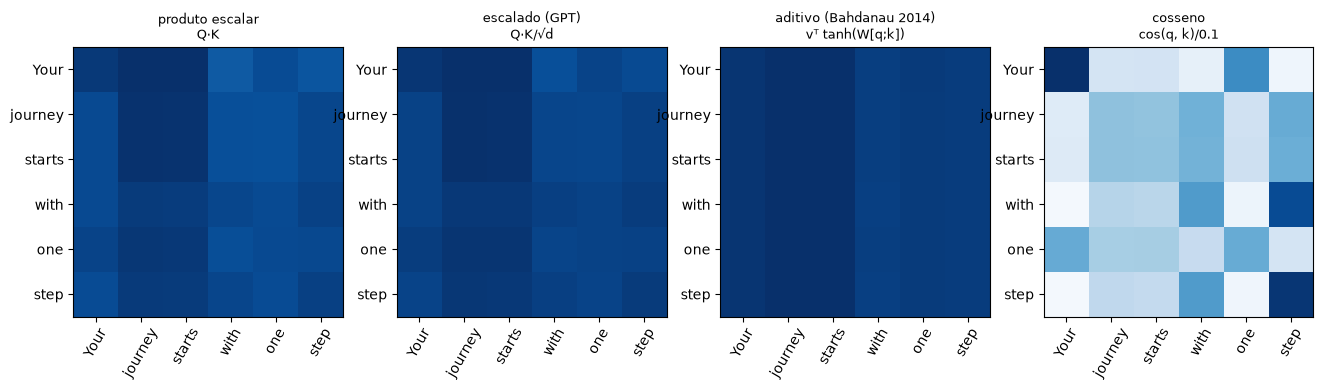

In [3]:
torch.manual_seed(0)
W_a = torch.nn.Linear(2 * d_k, 4)
v_a = torch.nn.Linear(4, 1, bias=False)
aditivo = v_a(torch.tanh(W_a(torch.cat(torch.broadcast_tensors(Q[:, None], K[None, :]), dim=-1)))).squeeze(-1)

variantes = {
    "produto escalar\nQ·K": scores,
    "escalado (GPT)\nQ·K/√d": scores / d_k**0.5,
    "aditivo (Bahdanau 2014)\nvᵀ tanh(W[q;k])": aditivo,
    "cosseno\ncos(q, k)/0.1": torch.nn.functional.cosine_similarity(Q[:, None], K[None, :], dim=-1) / 0.1,
}
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, (nome, s) in zip(axs, variantes.items()):
    mapa(ax, torch.softmax(s, dim=-1), nome)
plt.show()

**Por que dividir por √d?** Com vetores grandes, o produto escalar cresce e o softmax vira quase *one-hot* (gradiente some):

In [4]:
for d in [2, 64, 768]:
    q, k = torch.randn(d), torch.randn(10, d)
    s = k @ q
    print(f"d={d:>3}: maior peso sem escala = {torch.softmax(s, 0).max():.2f} | com escala = {torch.softmax(s / d**0.5, 0).max():.2f}")

d=  2: maior peso sem escala = 0.45 | com escala = 0.33
d= 64: maior peso sem escala = 0.95 | com escala = 0.26
d=768: maior peso sem escala = 1.00 | com escala = 0.24


Variações modernas mexem em **quais** Q/K/V são calculados, não tanto na fórmula do score:
GQA (várias queries compartilham K/V — Llama), MLA (K/V comprimidos — DeepSeek), janela deslizante (Mistral/Gemma),
atenção linear / DeltaNet (sem softmax, custo linear). Código no repo: `ch04/04_gqa`, `05_mla`, `06_swa`, `08_deltanet`.

## 3. Máscara causal: o GPT não pode olhar o futuro

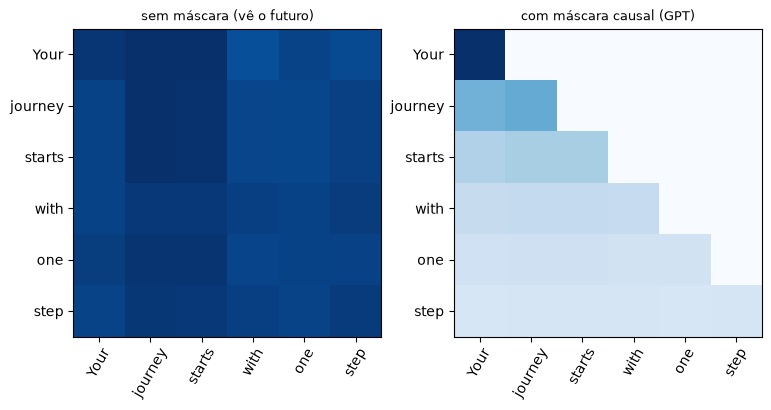

In [5]:
n = len(tokens)
mascara = torch.triu(torch.ones(n, n), diagonal=1).bool()
s_mascarado = (scores / d_k**0.5).masked_fill(mascara, -torch.inf)  # -inf vira 0 depois do softmax

fig, axs = plt.subplots(1, 2, figsize=(9, 4))
mapa(axs[0], torch.softmax(scores / d_k**0.5, -1), "sem máscara (vê o futuro)")
mapa(axs[1], torch.softmax(s_mascarado, -1), "com máscara causal (GPT)")
plt.show()

## 4. Multi-head: várias atenções em paralelo
A `MultiHeadAttention` do livro **fatia** `d_out` em `num_heads` pedaços de `head_dim = d_out / num_heads`.
Ela não devolve os pesos, então reproduzimos seus passos até o softmax para poder desenhá-los:

In [6]:
def pesos_atencao(mha, x):
    """Mesmo cálculo de MultiHeadAttention.forward, parando nos pesos: (batch, heads, tokens, tokens)."""
    b, t, _ = x.shape
    q = mha.W_query(x).view(b, t, mha.num_heads, mha.head_dim).transpose(1, 2)
    k = mha.W_key(x).view(b, t, mha.num_heads, mha.head_dim).transpose(1, 2)
    s = (q @ k.transpose(2, 3)).masked_fill(mha.mask.bool()[:t, :t], -torch.inf)
    return torch.softmax(s / mha.head_dim**0.5, dim=-1)

In [7]:
# 🔧 Mudando o número de heads: parâmetros e formato de saída NÃO mudam, só como d_out é fatiado
X = torch.randn(1, 6, 768)
for h in [1, 2, 4, 12, 24]:
    mha = MultiHeadAttention(d_in=768, d_out=768, context_length=1024, dropout=0.0, num_heads=h)
    print(f"heads={h:>2}  head_dim={mha.head_dim:>3}  params={sum(p.numel() for p in mha.parameters()):,}"
          f"  saída={tuple(mha(X).shape)}  pesos={tuple(pesos_atencao(mha, X).shape)}")

heads= 1  head_dim=768  params=2,360,064  saída=(1, 6, 768)  pesos=(1, 1, 6, 6)
heads= 2  head_dim=384  params=2,360,064  saída=(1, 6, 768)  pesos=(1, 2, 6, 6)
heads= 4  head_dim=192  params=2,360,064  saída=(1, 6, 768)  pesos=(1, 4, 6, 6)
heads=12  head_dim= 64  params=2,360,064  saída=(1, 6, 768)  pesos=(1, 12, 6, 6)
heads=24  head_dim= 32  params=2,360,064  saída=(1, 6, 768)  pesos=(1, 24, 6, 6)


Mais heads = mais "pontos de vista" independentes, cada um com menos dimensões.
Poucas heads → cada uma é rica mas há menos padrões; muitas → cada head_dim fica pequena demais.
GPT-2 mantém **head_dim = 64** em todos os tamanhos (768/12, 1024/16, 1280/20, 1600/25).

## 5. E se não for divisível?

In [8]:
try:
    MultiHeadAttention(d_in=768, d_out=768, context_length=1024, dropout=0.0, num_heads=5)
except AssertionError as e:
    print("AssertionError:", e)
print("768 / 5 =", 768 / 5, "→ não dá para fazer .view(b, t, 5, 153.6)")

AssertionError: d_out must be divisible by n_heads
768 / 5 = 153.6 → não dá para fazer .view(b, t, 5, 153.6)


O `.view` precisa dividir o vetor em partes inteiras e iguais. Saídas usadas na prática:
escolher `head_dim` explicitamente e fazer `d_out = num_heads × head_dim` (Llama/Gemma/Qwen definem `head_dim` no config)
e projetar de volta para `emb_dim` na `out_proj`.

In [9]:
# Exemplo: 5 heads de 64 → d_out=320, e a out_proj devolve 320 → 768 seria o próximo passo
mha5 = MultiHeadAttention(d_in=768, d_out=5 * 64, context_length=1024, dropout=0.0, num_heads=5)
print(tuple(mha5(X).shape))

(1, 6, 320)


## 6. Scores de verdade: as 12 heads de uma camada do GPT-2 treinado

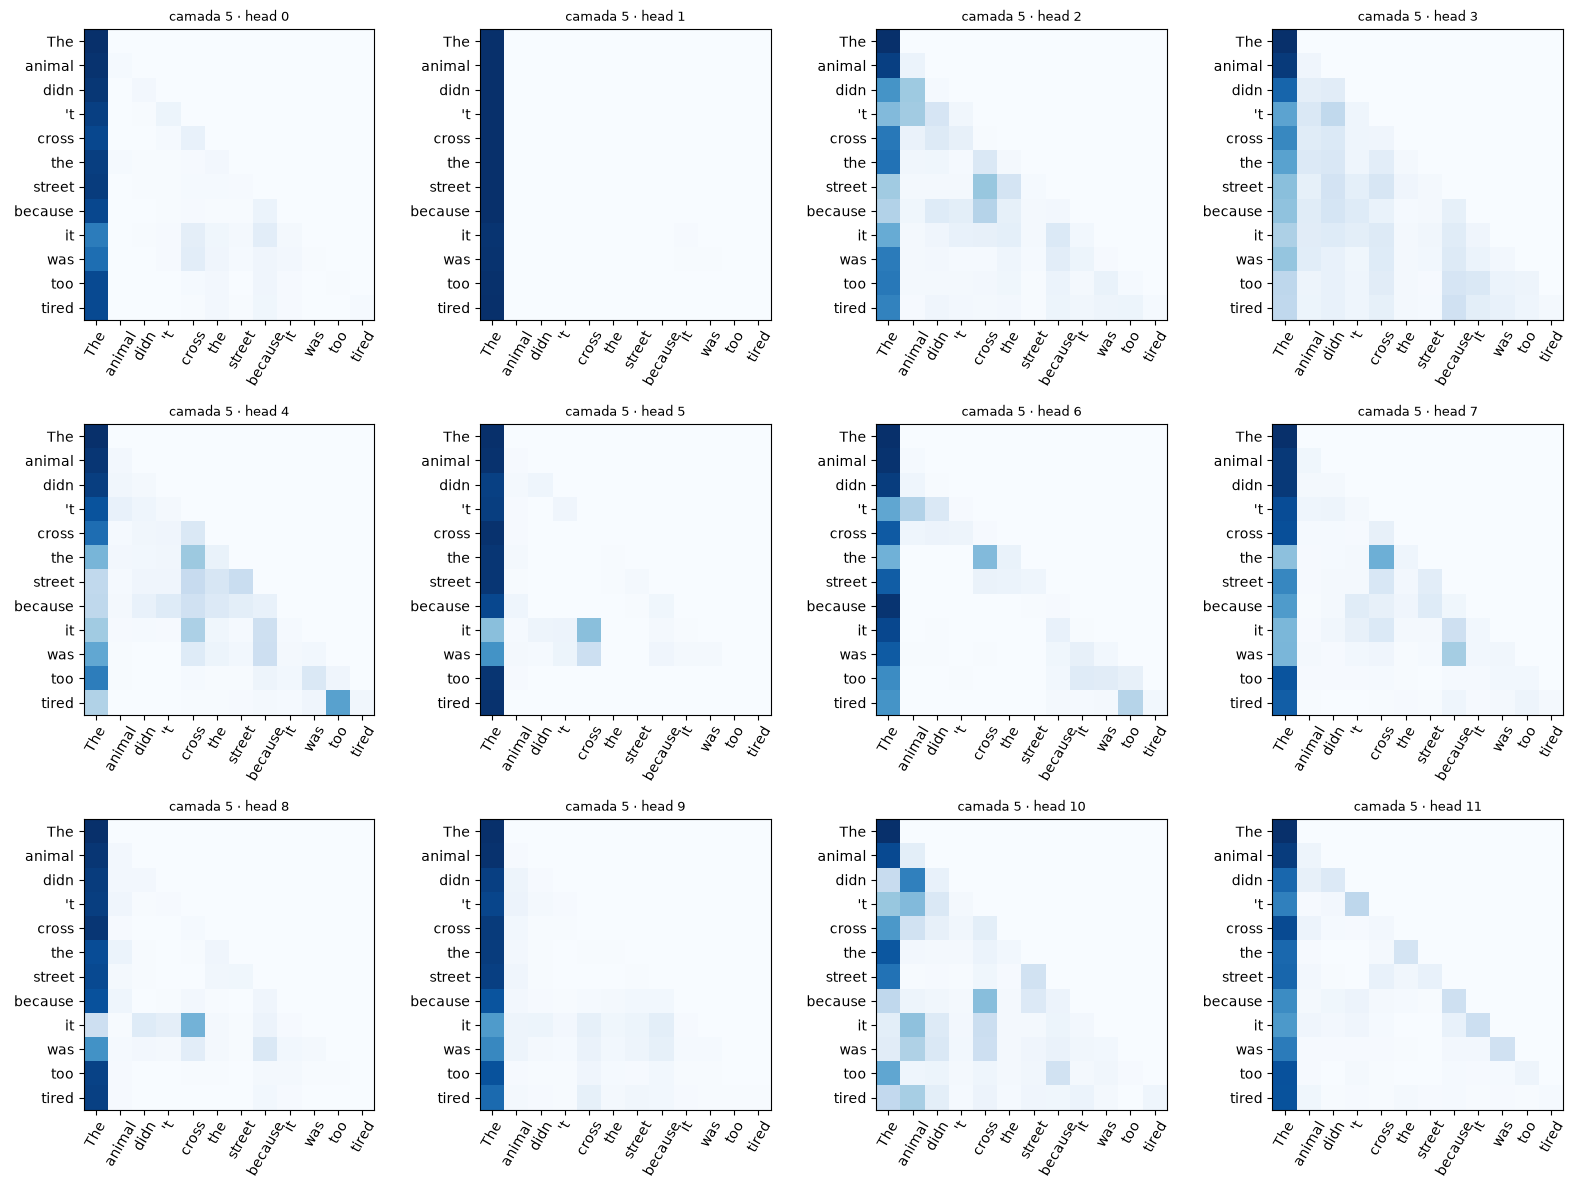

In [10]:
gpt2, _ = load_gpt2("124M")
bpe = tiktoken.get_encoding("gpt2")
frase = "The animal didn't cross the street because it was too tired"
ids = torch.tensor([bpe.encode(frase)])
rotulos = [bpe.decode([i]) for i in ids[0]]

CAMADA = 5  # 🔧 troque a camada (0–11) e veja os padrões mudarem
with torch.no_grad():
    h = gpt2.tok_emb(ids) + gpt2.pos_emb(torch.arange(ids.shape[1]))
    for bloco in gpt2.trf_blocks[:CAMADA]:
        h = bloco(h)
    bloco = gpt2.trf_blocks[CAMADA]
    P = pesos_atencao(bloco.att, bloco.norm1(h))[0]

fig, axs = plt.subplots(3, 4, figsize=(16, 12))
for head, ax in enumerate(axs.flat):
    mapa(ax, P[head], f"camada {CAMADA} · head {head}", rotulos)
plt.tight_layout()
plt.show()

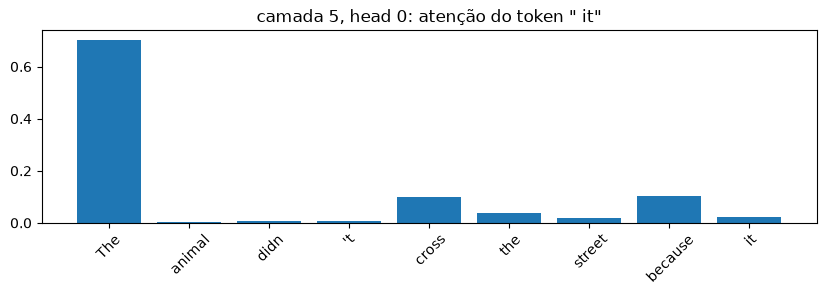

In [11]:
# Uma head só, e para onde " it" olha
HEAD = 0  # 🔧
i_it = rotulos.index(" it")
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.bar(rotulos[: i_it + 1], P[HEAD, i_it, : i_it + 1])
ax.set_title(f'camada {CAMADA}, head {HEAD}: atenção do token " it"')
plt.xticks(rotation=45)
plt.show()

### ✅ Construto
`MultiHeadAttention(d_in, d_out, context_length, dropout, num_heads)` — no notebook **03** ela vira uma peça do `TransformerBlock`.